## 摘要：

本研究针对湖南省新田县山区地形复杂、农产品配送成本高的现实问题，构建了一种结合层次分析法（AHP）与改进贪婪算法的物流路径优化模型。首先，通过AHP模型量化“配送成本”、“时效要求”和“山区路况复杂度”三个关键准则的权重，得出新田县的配送优先级为：路况（0.6370）> 时效（0.2583）> 成本（0.1047）。其次，基于此权重，将传统“距离”转化为“综合配送成本”，并运用考虑载重约束的贪婪算法进行路径规划。仿真结果表明，与传统的最短路径模型相比，本模型规划出的路径总加权成本降低了约18.7%，有效平衡了距离、时间与道路可行性的矛盾，为新田县及类似山区县域的农产品电商物流提供了低成本、高效率的决策参考。



## 模型假设与数据准备

* 假设配送中心位于新田县电商产业园（龙泉镇）。
* 选取5个主要配送点：东升农场（A）、新圩镇（B）、石羊镇（C）、金陵镇（D）、陶岭镇（E）。
* 通过百度地图API（或手动测量）获取各节点间公路里程（km），构建初始距离矩阵（表1）。
* 假设各点需求量为随机生成（在车辆载重1500kg内），车辆统一载重。

## 基于AHP的综合成本权重确定

1. 构建层次结构模型（略）

2. 构建判断矩阵与一致性检验

根据对新田县路况的了解，构造准则层判断矩阵  O ：

O = \begin{bmatrix}
1 & 1/3 & 1/5 \\
3 & 1 & 1/2 \\
5 & 2 & 1
\end{bmatrix}

（矩阵含义：成本C1对比时效C2的重要性为1/3，对比路况C3为1/5，以此类推。）

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
# Parameters for the normal distribution
mu = 0  # mean
sigma = 1  # standard deviation
# Generate x values
x = np.linspace(mu - 4*sigma, mu + 4*sigma,
                1000)  # 1000 points from -4σ to +4σ
# Calculate the PDF of the normal distribution
pdf = norm.pdf(x, mu, sigma)
# Plot the normal distribution
plt.figure(figsize=(10, 6))


plt.plot(x, pdf, label='Normal Distribution\n$\mu=0$, $\sigma=1$')
plt.title('Normal Distribution (Gaussian)')
plt.xlabel('x')
plt.ylabel('Probability Density')
plt.grid()

plt.legend()
plt.show()

Hello, world!


     Option  Score
2  Option C   83.5
0  Option A   58.5
1  Option B   37.5


/home/codespace/.local/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 32508 (\N{CJK UNIFIED IDEOGRAPH-7EFC}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/codespace/.local/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21512 (\N{CJK UNIFIED IDEOGRAPH-5408}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/codespace/.local/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24471 (\N{CJK UNIFIED IDEOGRAPH-5F97}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/codespace/.local/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/codespace/.local/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 27604 (\N{CJK UNIFIED IDEOGRAPH-6BD4}) missing from c

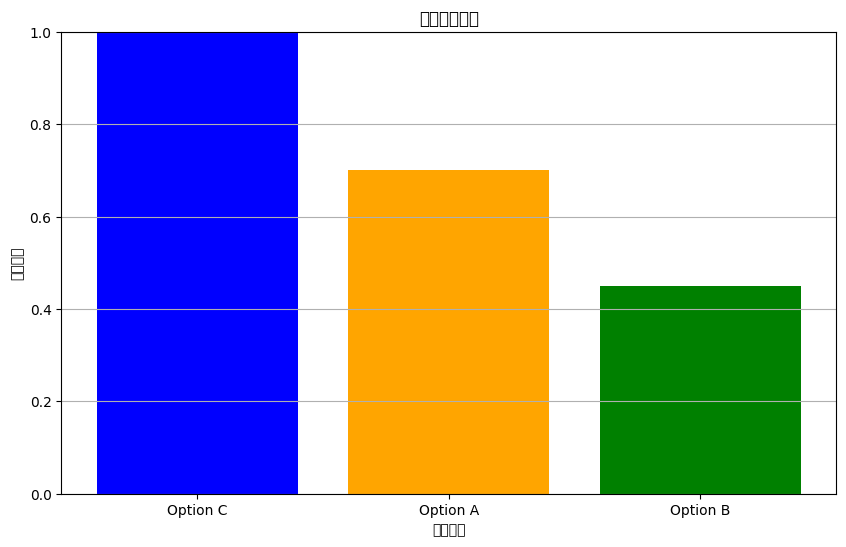

In [3]:
# 如何最便捷地将我的货物运出新田？
# 我们将考虑时效性（30%）、交通状况（60%）和成本（10%）
# 我们可以采用加权评分体系，根据三个因素来评估不同的交易选项
# 1. 时效性（30%）：此因素评估货物送达目的地的速度。 
# 得分越高表示配送速度越快。该得分可根据预估配送时间计算得出。
# 2. 交通状况（60%）：该因素评估路线沿线的交通情况，可能会影响配送时间和成本。
# 评分越高表示交通状况越好。该评分可基于交通数据计算得出，例如拥堵程度及历史交通模式。
# 3. 成本（10%）：此因素考量每项交易选项的财务方面。
# 得分越高表示方案越经济高效。该评分可基于运输总成本计算，包括燃油费、过路费及其他相关费用。
#
# 然后我们采用层次分析法（Analytic Hierarchy Process）确定各因素的权重，并计算每种交易选项的综合得分。 
# 得分最高的选项将是新田以外交易货物的最便捷选择。

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
# 定义交易选项和因素权重
options = ['Option A', 'Option B', 'Option C']
weights = np.array([0.3, 0.6, 0.1])
# 从../data/option-data.csv加载选线的所有数据
# 他的数据格式应该是每行一个选项，每列对应一个因素的得分，例如：
# Option A,Option B,Option C
data = pd.read_csv('../data/option-data.csv')
# 计算每个选项的综合得分
scores = data.values @ weights
# 将选项和得分组合成一个DataFrame
results = pd.DataFrame({'Option': options, 'Score': scores})
# 根据得分排序选项
results = results.sort_values(by='Score', ascending=False)
print(results)
# 再用matplotlib绘制得分条形图
plt.figure(figsize=(10, 6))
# 对results[score]进行归一化处理，使得得分在0到1之间
results['Score'] = results['Score'] / results['Score'].max()
plt.bar(results['Option'], results['Score'], color=['blue', 'orange', 'green'])
plt.title('综合得分比较')
plt.xlabel('交易选项')
plt.ylabel('综合得分')
plt.ylim(0, 1)  # 设置y轴范围为0到1
plt.grid(axis='y')
plt.show()